# Figure 2 and Figure F.1: well-specified simulation (R1)

Reads the per-replication rows written by

```bash
python -m experiments.simulation.r1_main --config main10 --row both --seeds 0:50
python -m experiments.simulation.r1_main --config app20  --row both --seeds 0:50
```

and renders the two-row, five-column simulation figures into this repo's `figures/`
directory (`r1_main10.pdf`, `r1_app20.pdf`). No analysis happens here: aggregation
(means, Monte Carlo standard errors, selection rates, exclusion of non-convergent
replications) lives in `experiments/simulation/r1_plot.py`, so the figure can be
restyled without re-running anything. Rows can be appended with a new `--seeds a:b`
range; this notebook always aggregates everything stored.

**Row 1** varies the human budget $n_0$ at an abundant LLM budget under the exact model,
with the first-order excess risks $(N-1)/(2n_0)$ and $(r+1)/(2n_0)$ of the risk-tradeoff
theorem as dotted lines. **Row 2** varies the LLM budget $n_L$ at fixed $n_0$ with
pair-level LLM overdispersion, the regime in which the oracle weight differs from the
joint-likelihood weight $n_L/n_0$ and GACV adapts.

Colours are categorical slots of the validated reference palette (all six checks pass)
and marker shape is a redundant identity encoding. Coverage uses the judge–pair
cluster-robust sandwich; the interval for DIAL at $\widehat\lambda$ is post-selection.


In [1]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
from experiments.simulation.r1_plot import COLS, aggregate, load  # noqa: E402

FIGURES = REPO / "figures"
FIGURES.mkdir(exist_ok=True)

# Validated categorical palette (dataviz reference instance, slots 1, 2, 3, 7, 5, 4);
# marker shape is the second encoding of estimator identity.
STYLE = {
    "human_only": dict(color="#2a78d6", marker="o", label=r"Human-only ($\lambda=0$)"),
    "staged": dict(color="#eb6834", marker="s", label=r"DIAL-staged ($\lambda=\infty$)"),
    "dial_mle": dict(color="#1baf7a", marker="^", label=r"DIAL-MLE ($\lambda=n_L/n_0$)"),
    "dial": dict(color="#4a3aa7", marker="D", label=r"DIAL ($\widehat\lambda$ by GACV)"),
    "oracle_lambda": dict(color="#4a3aa7", marker=None, ls="--", label=r"oracle $\lambda$"),
    "dial_nodeb": dict(color="#e87ba4", marker="v", label="DIAL-noDeb"),
    "consensus_cal": dict(color="#eda100", marker="P", label="Consensus-only"),
}
PANELS = [  # (column in rows.jsonl, panel title, log y)
    ("excess", "excess human risk", True),
    ("sign_acc", "pairwise sign accuracy", False),
    ("spearman", r"Spearman$(\hat s, s_0)$", False),
    ("cov_s", "95% CI coverage", False),
    ("b_rmse", r"RMSE$(\hat b, b)$", True),
]


## Load and aggregate

`load` marks a replication irregular when the staged or joint-MLE fit is flagged as
non-convergent (separation in a judge–item cell at the smallest LLM budgets);
`aggregate` averages over the regular replications and counts the excluded ones.


In [2]:
frames = {}
for cfg in ("main10", "app20"):
    path = REPO / "results" / "r1" / cfg / "rows.jsonl"
    if not path.exists():
        print(f"{cfg}: no rows at {path}; run r1_main.py first")
        continue
    df = load(cfg, base=REPO)
    agg = aggregate(df)
    frames[cfg] = (df, agg)
    n_seeds = df.seed.nunique()
    n_irr = int(df[df.irregular][["row", "n_L", "n_0", "seed"]].drop_duplicates().shape[0])
    print(f"{cfg}: N={int(df.N.iloc[0])}, K={int(df.K.iloc[0])}, r={int(df.r.iloc[0])}, seeds={n_seeds}, "
          f"cells={df[['row','n_L','n_0']].drop_duplicates().shape[0]}, irregular replications excluded={n_irr}")


main10: N=10, K=4, r=1, seeds=50, cells=11, irregular replications excluded=5
app20: N=20, K=6, r=2, seeds=50, cells=11, irregular replications excluded=0


/home/claude/DIAL/experiments/simulation/r1_plot.py:49: RuntimeWarning: All-NaN slice encountered
  lam_med=("lam", lambda x: np.nanmedian(x.replace(np.inf, np.nan))) if "lam" in reg else ("seed", "size"),
/home/claude/DIAL/experiments/simulation/r1_plot.py:49: RuntimeWarning: All-NaN slice encountered
  lam_med=("lam", lambda x: np.nanmedian(x.replace(np.inf, np.nan))) if "lam" in reg else ("seed", "size"),


## Figure

Drawn at the final physical width of the ICLR text block (5.5 in) so that fonts are
true size in the PDF. Lower error bars that would cross zero on the log scale are
clipped by the axis.


wrote figures/r1_main10.pdf  (50 replications)


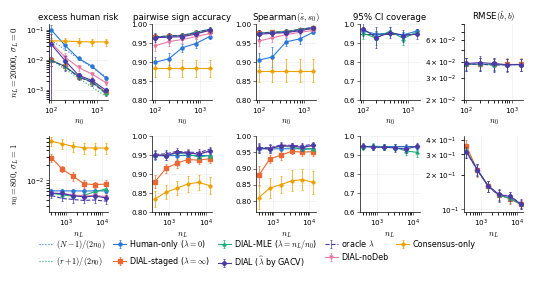

wrote figures/r1_app20.pdf  (50 replications)


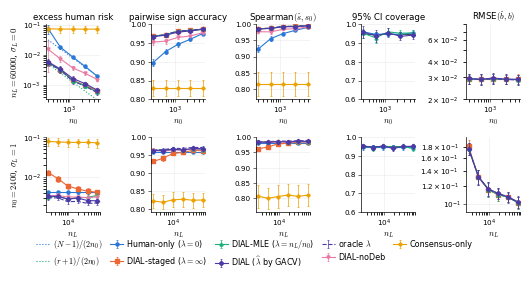

In [3]:
def draw(agg, N, r, out, seeds):
    mpl.rcParams.update({"font.size": 6, "axes.titlesize": 6.2, "axes.labelsize": 6, "xtick.labelsize": 5.2,
                         "ytick.labelsize": 5.2, "legend.fontsize": 5.8, "axes.linewidth": 0.5,
                         "xtick.major.width": 0.4, "ytick.major.width": 0.4, "xtick.major.size": 2,
                         "ytick.major.size": 2, "mathtext.fontset": "cm"})
    fig, axes = plt.subplots(2, 5, figsize=(5.5, 2.75))
    ms, lw, cs, elw = 2.2, 0.8, 1.0, 0.5
    for ri, (row, xcol, xlabel) in enumerate([("n0", "n_0", "$n_0$"), ("nL", "n_L", "$n_L$")]):
        d = agg[agg.row == row]
        for ci, (col, title, logy) in enumerate(PANELS):
            ax = axes[ri, ci]
            if col == "excess" and row == "n0":
                x = np.array(sorted(d.n_0.unique()), float)
                ax.plot(x, (N - 1) / (2 * x), ":", color=STYLE["human_only"]["color"], lw=lw, label="$(N-1)/(2n_0)$")
                ax.plot(x, (r + 1) / (2 * x), ":", color=STYLE["dial_mle"]["color"], lw=lw, label="$(r+1)/(2n_0)$")
            for m, st in STYLE.items():
                s_ = d[d.method == m].sort_values(xcol)
                y = s_[f"{col}_mean"].values
                if np.all(np.isnan(y)):
                    continue
                ax.errorbar(s_[xcol], y, yerr=1.96 * s_[f"{col}_se"].values, color=st["color"], marker=st.get("marker"),
                            ms=ms, ls=st.get("ls", "-"), lw=lw, elinewidth=elw, capsize=cs, capthick=elw,
                            label=st["label"], zorder=3 if m == "dial" else 2)
            if col == "cov_s":
                ax.axhline(0.95, color="k", lw=0.5, zorder=1)
                ax.set_ylim(0.6, 1.0)
            if col in ("sign_acc", "spearman"):
                ax.set_ylim(min(0.8, ax.get_ylim()[0]), 1.0)
            if col == "b_rmse" and row == "n0":
                ax.set_ylim(0.02, 0.08)
            if col == "excess":
                ax.set_ylim(np.nanmin(d[f"{col}_mean"].values) * 0.6, ax.get_ylim()[1])
            ax.set_xscale("log")
            if logy:
                ax.set_yscale("log")
            ax.set_xlabel(xlabel, labelpad=1)
            if ri == 0:
                ax.set_title(title, pad=3)
            ax.grid(alpha=0.25, which="major", lw=0.4)
            ax.tick_params(pad=1.5)
            for sp in ("top", "right"):
                ax.spines[sp].set_visible(False)
        fixed = f"$n_L={int(d.n_L.iloc[0])}$" if row == "n0" else f"$n_0={int(d.n_0.iloc[0])}$"
        sig = float(d.sigma_L.iloc[0])
        axes[ri, 0].annotate(rf"{fixed}, $\sigma_L={sig:g}$", xy=(-0.55, 0.5), xycoords="axes fraction",
                             rotation=90, va="center", ha="center", fontsize=6.2)
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.005),
               handlelength=1.6, columnspacing=1.0, handletextpad=0.4)
    fig.tight_layout(rect=(0.02, 0.10, 1, 1.0), w_pad=0.6, h_pad=0.8)
    fig.savefig(out.with_suffix(".pdf"))
    fig.savefig(out.with_suffix(".png"), dpi=300)
    print(f"wrote {out.with_suffix('.pdf').relative_to(REPO)}  ({seeds} replications)")
    return fig


for cfg, (df, agg) in frames.items():
    fig = draw(agg, int(df.N.iloc[0]), int(df.r.iloc[0]), FIGURES / f"r1_{cfg}", df.seed.nunique())
    plt.show()


## Numbers quoted in the paper

Excess risk, Spearman, and coverage per cell for the estimators discussed in the text,
plus the GACV selection rates. The binomial-sandwich coverage (`cov_s_iid`) is stored
alongside the cluster-robust one (`cov_s`) so the under-coverage under overdispersion
can be quoted from the same replications.


In [4]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
show = ["row", "n_L", "n_0", "method", "n", "excess_mean", "spearman_mean", "cov_s_mean", "cov_s_iid_mean",
        "b_rmse_mean", "lam_med", "lam_zero_frac", "lam_inf_frac", "n_irregular"]
for cfg, (df, agg) in frames.items():
    print(f"== {cfg}")
    print(agg[agg.method.isin(["human_only", "staged", "dial_mle", "dial", "oracle_lambda"])][show].round(4).to_string(index=False))


== main10
row   n_L  n_0        method  n  excess_mean  spearman_mean  cov_s_mean  cov_s_iid_mean  b_rmse_mean  lam_med  lam_zero_frac  lam_inf_frac  n_irregular
 n0 20000  100          dial 50       0.0330         0.9736      0.9778          0.9764       0.0391  20.0000         0.0400        0.6400          0.0
 n0 20000  100      dial_mle 50       0.0098         0.9767      0.9538          0.9569       0.0385 200.0000         0.0000        0.0000          0.0
 n0 20000  100    human_only 50       0.0999         0.9057      0.9662             NaN          NaN      NaN         0.0000        0.0000          0.0
 n0 20000  100 oracle_lambda 50       0.0096         0.9767         NaN             NaN       0.0387  20.0000         0.0000        0.4800          0.0
 n0 20000  100        staged 50       0.0097         0.9767         NaN             NaN       0.0385      NaN         0.0000        0.0000          0.0
 n0 20000  200          dial 50       0.0096         0.9762      0.9294       

### GACV selecting the human-only endpoint at small $n_0$

Mean versus median excess risk of DIAL at $\widehat\lambda$ against the joint MLE, and the
replications in which $\widehat\lambda=0$ was selected. A nearly separated human-only fit
that passes the regularity guard can dominate the mean at $n_0\le200$.


In [5]:
df, _ = frames["main10"]
d = df[(df.row == "n0") & (df.method.isin(["dial", "dial_mle"])) & (~df.irregular)]
print(d.groupby(["n_0", "method"]).excess.agg(mean="mean", median="median", q90=lambda x: x.quantile(0.9)).round(4))
sel0 = df[(df.method == "dial") & (df.lam == 0)][["row", "n_L", "n_0", "seed", "excess"]].sort_values(["row", "n_0", "n_L"])
print(f"\nreplications with lambda_hat = 0: {len(sel0)}")
print(sel0.to_string(index=False))


                 mean  median     q90
n_0  method                          
100  dial      0.0330  0.0073  0.0329
     dial_mle  0.0098  0.0066  0.0217
200  dial      0.0096  0.0049  0.0181
     dial_mle  0.0062  0.0040  0.0153
400  dial      0.0031  0.0026  0.0064
     dial_mle  0.0028  0.0024  0.0057
800  dial      0.0021  0.0017  0.0041
     dial_mle  0.0019  0.0014  0.0037
1600 dial      0.0010  0.0008  0.0017
     dial_mle  0.0008  0.0006  0.0014

replications with lambda_hat = 0: 16
row   n_L  n_0  seed   excess
 n0 20000  100    27 0.981487
 n0 20000  100    36 0.162765
 n0 20000  200     7 0.064449
 n0 20000  200    17 0.061841
 n0 20000  200    48 0.045618
 nL   400  800     8 0.007653
 nL   400  800    20 0.009799
 nL   400  800    33 0.004363
 nL   800  800    34 0.005912
 nL  1600  800    12 0.003420
 nL 12800  800    12 0.003420
 nL 12800  800    13 0.004645
 nL 12800  800    19 0.007143
 nL 12800  800    23 0.013038
 nL 12800  800    26 0.007594
 nL 12800  800    32 0.005